# GIST descriptor (colour)

The colour variant looks at all the colours rather than the grayscale image only: the 512 value descriptor is computed independently for each of the B, G and R channels and concatenated into a 1536 value descriptor.

In [1]:
%matplotlib inline
import glob, os

import cv2
import numpy as np
import matplotlib.pyplot as plt

import gist_descriptor_colour as gcd

In [2]:
base_img = '../sample_images/images/input3.jpg'
base_gist = gcd.compute_gist_descriptor3(base_img)
print('colour descriptor shape:', base_gist.shape)

colour descriptor shape: (1536,)


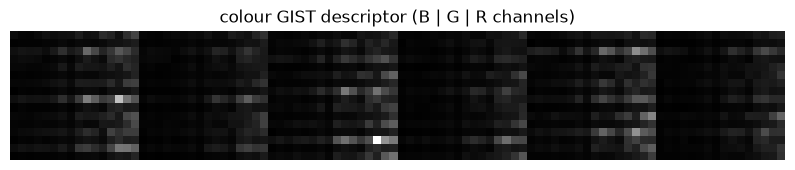

In [3]:
plt.figure(figsize=(10, 3))
plt.imshow(base_gist.reshape((16, 96)), cmap='gray')
plt.title('colour GIST descriptor (B | G | R channels)')
plt.axis('off');

## Rank candidate photos by colour descriptor distance

In [4]:
candidates = sorted(glob.glob('../sample_images/images/input3/*.jpg'))[:8]
distances = {}
for cand in candidates:
    distances[cand] = gcd.ssd(gcd.compute_gist_descriptor3(cand), base_gist)
for cand, d in sorted(distances.items(), key=lambda kv: kv[1]):
    print(f'{os.path.basename(cand):20s} ssd={d:10.2f}')

patch12.jpg          ssd=  12291.83
patch1.jpg           ssd=  13147.77
patch11.jpg          ssd=  14321.29
patch15.jpg          ssd=  14529.78
patch14.jpg          ssd=  14559.94
patch13.jpg          ssd=  16160.41
patch16.jpg          ssd=  16300.98
patch0.jpg           ssd=  16630.96


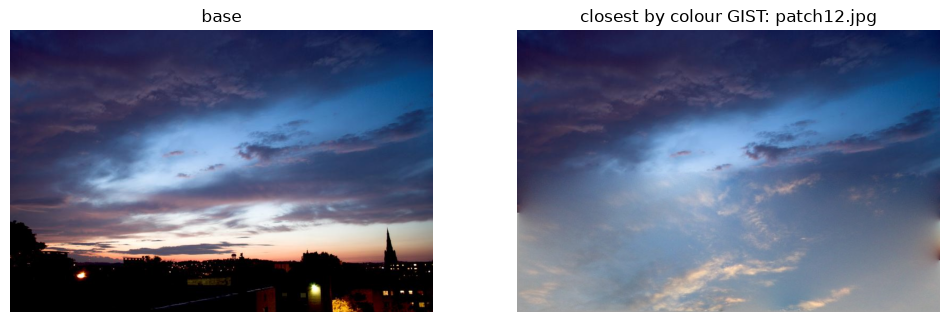

In [5]:
best_cand = min(distances, key=distances.get)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, title in zip(
        axes, [base_img, best_cand],
        ['base', f'closest by colour GIST: {os.path.basename(best_cand)}']):
    ax.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off');